In [1]:
# Importações básicas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Configurações de visualização
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Bibliotecas especializadas
# import missingno as msno
from scipy import stats
# import category_encoders as ce
import math
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

print(" Bibliotecas importadas!")

 Bibliotecas importadas!


Carregamento e Exploração de Dados

In [2]:
from pathlib import Path
import pandas as pd

path = Path('../../data/Airbnb Prices in European Cities/raw')

# arquivos
weekends = pd.read_csv(path / "barcelona_weekends.csv")
weekdays = pd.read_csv(path / "barcelona_weekdays.csv")

# junta os dois DataFrames linha a linha
df = pd.concat([weekdays, weekends], ignore_index=True)

print("Arquivos carregados e unidos!")
print(df.shape)


Arquivos carregados e unidos!
(2833, 20)


In [3]:
cols_lfs = [
    'version https://git-lfs.github.com/spec/v1',
    'oid sha256',
    'size'
]

df = df.drop(columns=[c for c in cols_lfs if c in df.columns])


Análise Exploratória Estrutural

In [4]:
# 1. Informações básicas do dataset
print("\n1️⃣ INFORMAÇÕES GERAIS:")
print(f"Dimensões: {df.shape}")
print(f"Memória: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")


1️⃣ INFORMAÇÕES GERAIS:
Dimensões: (2833, 20)
Memória: 0.54 MB


In [5]:
# 2. Tipos de dados
print("\n2️⃣ TIPOS DE DADOS:")
print(df.dtypes)


2️⃣ TIPOS DE DADOS:
Unnamed: 0                      int64
realSum                       float64
room_type                      object
room_shared                      bool
room_private                     bool
person_capacity               float64
host_is_superhost                bool
multi                           int64
biz                             int64
cleanliness_rating            float64
guest_satisfaction_overall    float64
bedrooms                        int64
dist                          float64
metro_dist                    float64
attr_index                    float64
attr_index_norm               float64
rest_index                    float64
rest_index_norm               float64
lng                           float64
lat                           float64
dtype: object


In [6]:
# 3. Primeiras linhas
print("\n3️⃣ PRIMEIRAS 5 LINHAS:")
display(df.head())


3️⃣ PRIMEIRAS 5 LINHAS:


,Unnamed: 0,realSum,room_type,room_shared,room_private,person_capacity,host_is_superhost,multi,biz,cleanliness_rating,guest_satisfaction_overall,bedrooms,dist,metro_dist,attr_index,attr_index_norm,rest_index,rest_index_norm,lng,lat
0,0,474.317499,Entire home/apt,False,False,4.0,False,0,1,10.0,91.0,1,1.111996,0.630491,526.469420,17.942927,915.587083,20.154890,2.17556,41.39624
1,1,169.897829,Private room,False,True,2.0,True,1,0,10.0,88.0,1,1.751839,0.124017,320.127526,10.910462,794.277350,17.484489,2.14906,41.38714
2,2,161.984779,Private room,False,True,4.0,False,0,1,9.0,88.0,1,1.670493,0.080322,344.073936,11.726595,840.673617,18.505814,2.15357,41.37859
3,3,367.956804,Entire home/apt,False,False,3.0,False,0,1,10.0,91.0,1,1.475847,0.093107,400.057449,13.634603,946.589884,20.837357,2.16839,41.37390
4,4,196.895292,Private room,False,True,3.0,False,1,0,9.0,91.0,1,1.855452,0.272486,346.042245,11.793678,792.296039,17.440874,2.15238,41.37699


In [7]:
# 4. Informações detalhadas
print("\n4️⃣ INFO DETALHADA:")
df.info()


4️⃣ INFO DETALHADA:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2833 entries, 0 to 2832
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Unnamed: 0                  2833 non-null   int64  
 1   realSum                     2833 non-null   float64
 2   room_type                   2833 non-null   object 
 3   room_shared                 2833 non-null   bool   
 4   room_private                2833 non-null   bool   
 5   person_capacity             2833 non-null   float64
 6   host_is_superhost           2833 non-null   bool   
 7   multi                       2833 non-null   int64  
 8   biz                         2833 non-null   int64  
 9   cleanliness_rating          2833 non-null   float64
 10  guest_satisfaction_overall  2833 non-null   float64
 11  bedrooms                    2833 non-null   int64  
 12  dist                        2833 non-null   float64
 13  metro_dist  

In [8]:
# 5. Estatísticas descritivas
print("\n5️⃣ ESTATÍSTICAS DESCRITIVAS:")
display(df.describe())


5️⃣ ESTATÍSTICAS DESCRITIVAS:


,Unnamed: 0,realSum,person_capacity,multi,biz,cleanliness_rating,guest_satisfaction_overall,bedrooms,dist,metro_dist,attr_index,attr_index_norm,rest_index,rest_index_norm,lng,lat
count,2833.000000,2833.000000,2833.000000,2833.000000,2833.000000,2833.000000,2833.000000,2833.000000,2833.000000,2833.000000,2833.000000,2833.000000,2833.000000,2833.000000,2833.000000,2833.000000
mean,714.521002,293.753706,2.616661,0.385104,0.325450,9.291564,91.109072,1.161313,2.116982,0.441248,460.767010,16.636220,881.070446,19.376528,2.169379,41.393495
std,420.492126,355.467888,1.153124,0.486706,0.468625,1.014577,8.607153,0.517108,1.377859,0.284540,264.421186,9.591798,466.379770,10.256285,0.019545,0.016138
min,0.000000,69.588289,2.000000,0.000000,0.000000,2.000000,20.000000,0.000000,0.095828,0.012994,93.820344,3.197553,159.835310,3.511045,2.093470,41.349540
25%,354.000000,160.821095,2.000000,0.000000,0.000000,9.000000,88.000000,1.000000,1.070443,0.256139,282.770925,10.160650,490.970310,10.788783,2.156640,41.381180
50%,708.000000,208.299393,2.000000,0.000000,0.000000,10.000000,93.000000,1.000000,1.732003,0.376994,386.259773,14.040570,808.624005,17.766466,2.170960,41.390390
75%,1062.000000,329.787977,3.000000,1.000000,1.000000,10.000000,97.000000,1.000000,2.967922,0.555944,589.721625,21.417238,1220.316291,26.806569,2.179730,41.404260
max,1554.000000,6943.700980,6.000000,1.000000,1.000000,10.000000,100.000000,6.000000,8.443967,4.039111,2934.133441,100.000000,4552.357526,100.000000,2.225520,41.463080


In [9]:
# 6. Análise de valores únicos
print("\n6️⃣ VALORES ÚNICOS POR COLUNA:")
for col in df.columns:
    unique_count = df[col].nunique()
    print(f"{col}: {unique_count}")


6️⃣ VALORES ÚNICOS POR COLUNA:
Unnamed: 0: 1555
realSum: 607
room_type: 3
room_shared: 2
room_private: 2
person_capacity: 5
host_is_superhost: 2
multi: 2
biz: 2
cleanliness_rating: 8
guest_satisfaction_overall: 41
bedrooms: 6
dist: 2833
metro_dist: 2833
attr_index: 2833
attr_index_norm: 2832
rest_index: 2833
rest_index_norm: 2832
lng: 1535
lat: 1451


Análise de Missing Values

In [10]:
# Contagem de missing values
print("\n1️⃣ MISSING VALUES POR COLUNA:")
missing_data = pd.DataFrame({
    'Coluna': df.columns,
    'Missing_Count': df.isnull().sum(),
    'Missing_Percent': (df.isnull().sum() / len(df)) * 100
})
missing_data = missing_data[missing_data['Missing_Count'] > 0].sort_values('Missing_Percent', ascending=False)
print(missing_data)


1️⃣ MISSING VALUES POR COLUNA:
Empty DataFrame
Columns: [Coluna, Missing_Count, Missing_Percent]
Index: []


Análise Exploratória Univariada

In [11]:
# Separar variáveis por tipo
numeric_vars = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_vars = df.select_dtypes(include=['object', 'bool']).columns.tolist()

In [12]:
print(f"Variáveis numéricas: {numeric_vars}")
print(f"Variáveis categóricas: {categorical_vars}")

Variáveis numéricas: ['Unnamed: 0', 'realSum', 'person_capacity', 'multi', 'biz', 'cleanliness_rating', 'guest_satisfaction_overall', 'bedrooms', 'dist', 'metro_dist', 'attr_index', 'attr_index_norm', 'rest_index', 'rest_index_norm', 'lng', 'lat']
Variáveis categóricas: ['room_type', 'room_shared', 'room_private', 'host_is_superhost']


In [13]:
# 1. ANÁLISE DE VARIÁVEIS NUMÉRICAS
print("\n1️⃣ ANÁLISE DE VARIÁVEIS NUMÉRICAS:")


1️⃣ ANÁLISE DE VARIÁVEIS NUMÉRICAS:


In [14]:
# Estatísticas descritivas detalhadas
for var in numeric_vars:
    if var in df.columns:
        print(f"\n📊 {var.upper()}:")
        data = df[var].dropna()

        # Estatísticas básicas
        print(f"  Mean: {data.mean():.2f}")
        print(f"  Median: {data.median():.2f}")
        print(f"  Std: {data.std():.2f}")
        print(f"  Skewness: {stats.skew(data):.2f}")
        print(f"  Kurtosis: {stats.kurtosis(data):.2f}")

        # Outliers (IQR method)
        Q1 = data.quantile(0.25)
        Q3 = data.quantile(0.75)
        IQR = Q3 - Q1
        outliers = data[(data < Q1 - 1.5*IQR) | (data > Q3 + 1.5*IQR)]
        print(f"  Outliers: {len(outliers)} ({len(outliers)/len(data)*100:.1f}%)")


📊 UNNAMED: 0:
  Mean: 714.52
  Median: 708.00
  Std: 420.49
  Skewness: 0.09
  Kurtosis: -1.08
  Outliers: 0 (0.0%)

📊 REALSUM:
  Mean: 293.75
  Median: 208.30
  Std: 355.47
  Skewness: 12.42
  Kurtosis: 210.39
  Outliers: 227 (8.0%)

📊 PERSON_CAPACITY:
  Mean: 2.62
  Median: 2.00
  Std: 1.15
  Skewness: 1.81
  Kurtosis: 2.14
  Outliers: 248 (8.8%)

📊 MULTI:
  Mean: 0.39
  Median: 0.00
  Std: 0.49
  Skewness: 0.47
  Kurtosis: -1.78
  Outliers: 0 (0.0%)

📊 BIZ:
  Mean: 0.33
  Median: 0.00
  Std: 0.47
  Skewness: 0.75
  Kurtosis: -1.44
  Outliers: 0 (0.0%)

📊 CLEANLINESS_RATING:
  Mean: 9.29
  Median: 10.00
  Std: 1.01
  Skewness: -2.65
  Kurtosis: 12.03
  Outliers: 133 (4.7%)

📊 GUEST_SATISFACTION_OVERALL:
  Mean: 91.11
  Median: 93.00
  Std: 8.61
  Skewness: -2.61
  Kurtosis: 13.56
  Outliers: 109 (3.8%)

📊 BEDROOMS:
  Mean: 1.16
  Median: 1.00
  Std: 0.52
  Skewness: 2.39
  Kurtosis: 9.80
  Outliers: 482 (17.0%)

📊 DIST:
  Mean: 2.12
  Median: 1.73
  Std: 1.38
  Skewness: 1.03
  Kurt

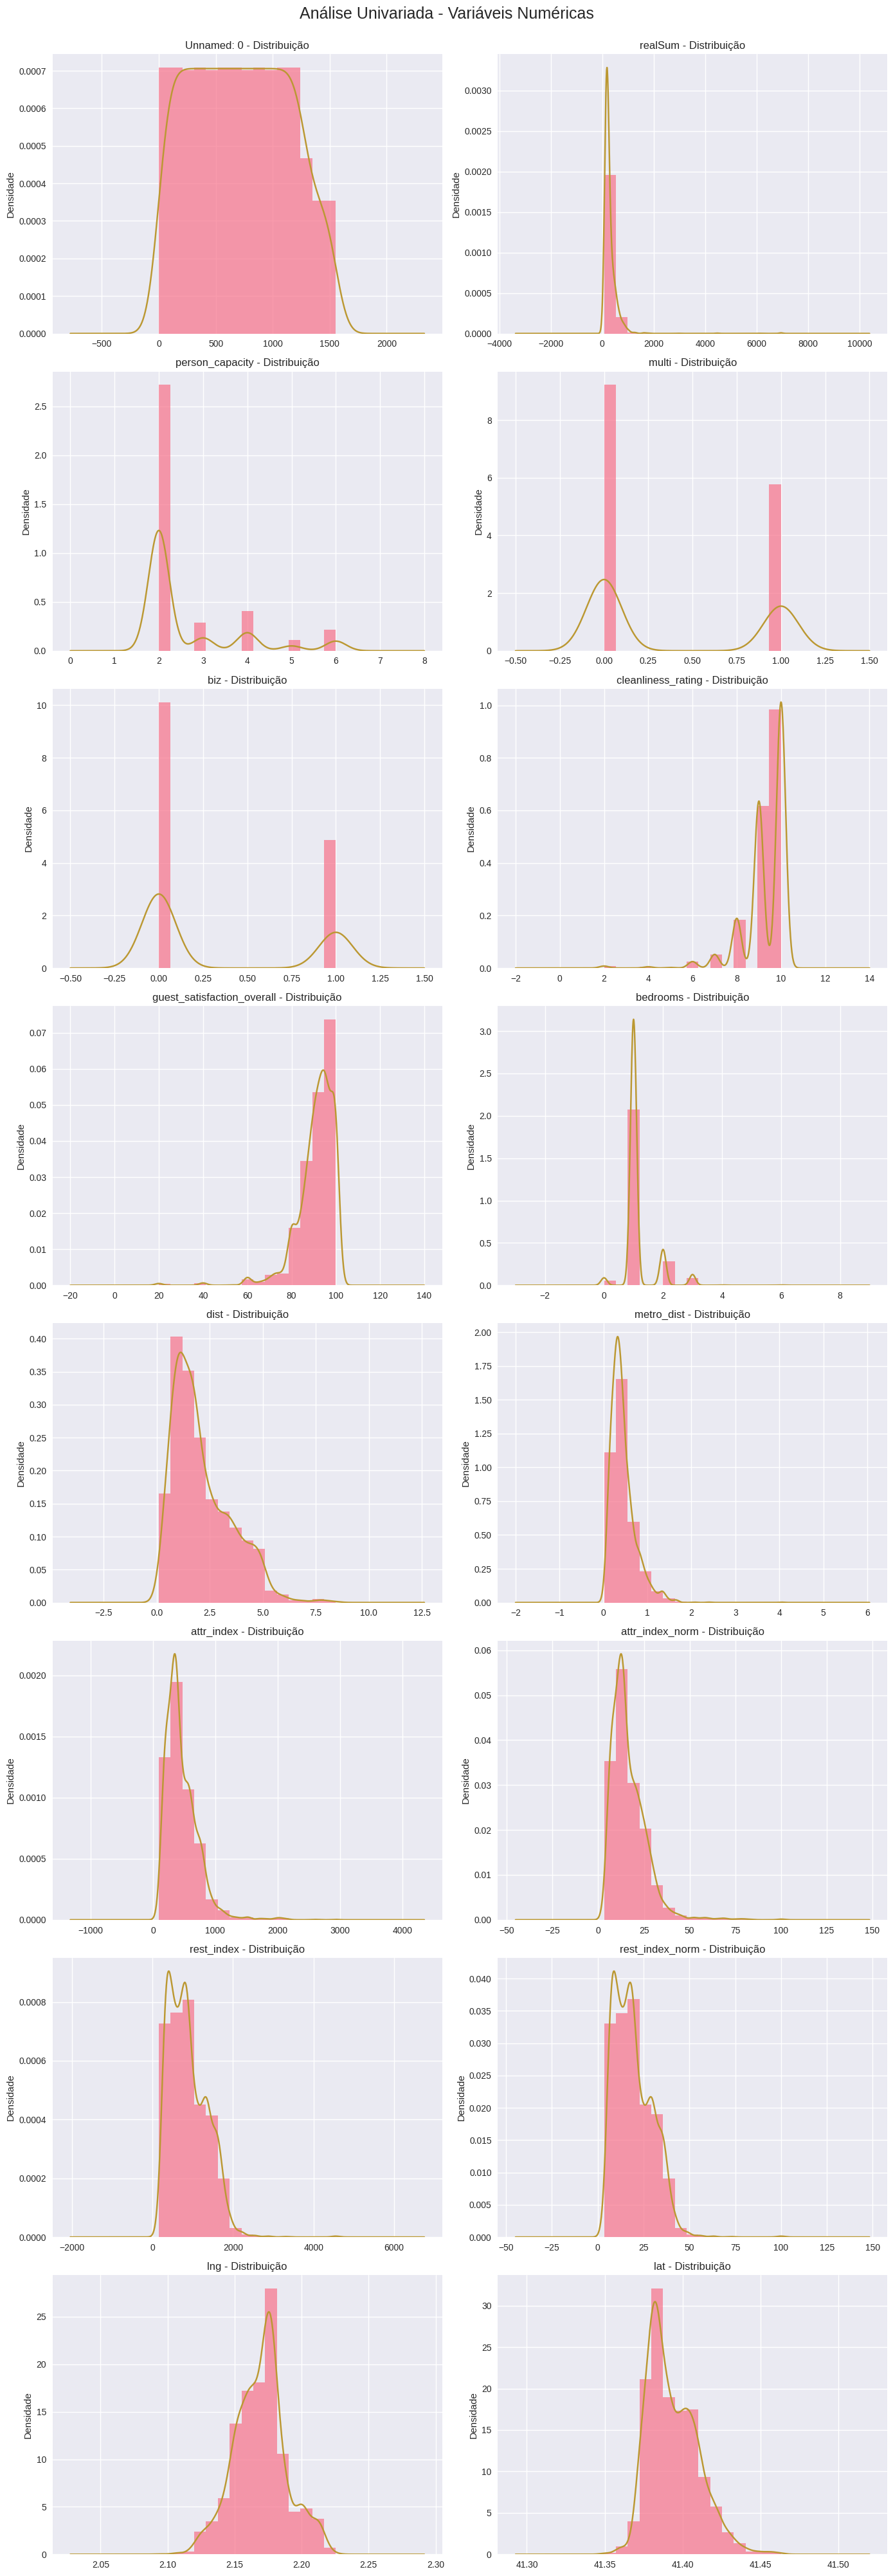

In [15]:
# Total das variáveis numéricas
vars_to_plot = numeric_vars[:16]   
cols = 2
rows = 8

fig, axes = plt.subplots(rows, cols, figsize=(14, 5 * rows))
fig.suptitle('Análise Univariada - Variáveis Numéricas', fontsize=18, y=1.0)

axes = axes.flatten()

for i, var in enumerate(vars_to_plot):
    ax = axes[i]

    
    # Histograma
    ax.hist(df[var].dropna(), bins=15, alpha=0.7, density=True)

    # Linha de densidade (KDE)
    df[var].dropna().plot.density(ax=ax)

    ax.set_title(f'{var} - Distribuição')
    ax.set_ylabel('Densidade')

plt.tight_layout()
plt.show()


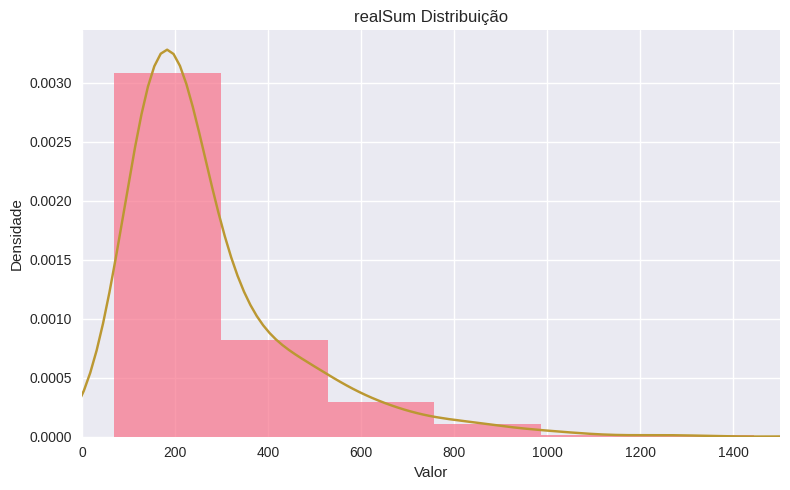

In [16]:
plt.figure(figsize=(8, 5))

plt.hist(df["realSum"].dropna(), bins=30, alpha=0.7, density=True)
df["realSum"].dropna().plot.density()

plt.title("realSum Distribuição")
plt.xlabel("Valor")
plt.ylabel("Densidade")

plt.xlim(0, 1500)   # escolha o valor ideal após observar o dataset

plt.tight_layout()
plt.show()


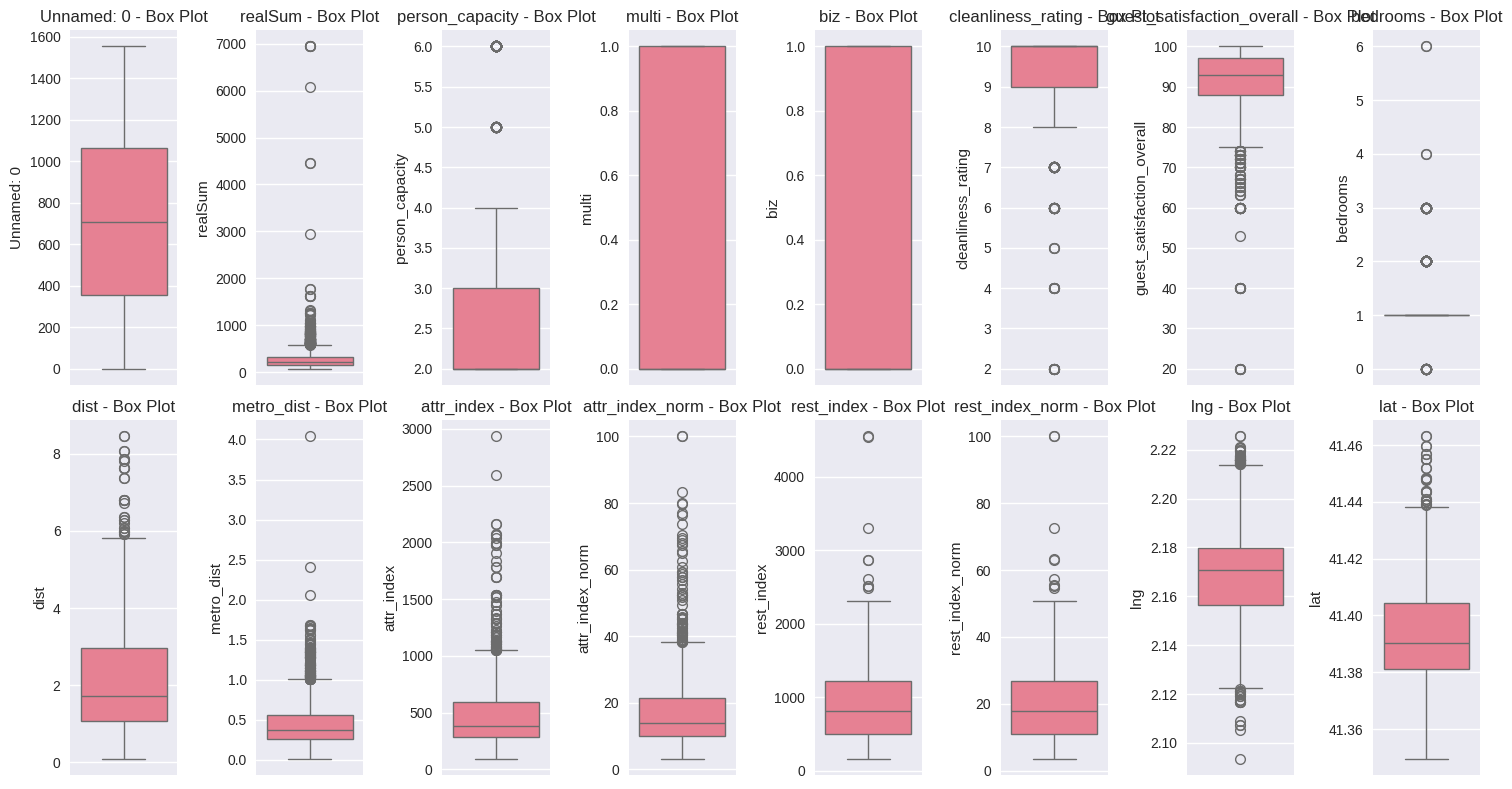

In [17]:
# Box plots para identificar outliers
plt.figure(figsize=(15, 8))
numeric_data = df[numeric_vars].select_dtypes(include=[np.number])

variables_to_plot = numeric_data.columns[:16]
for i, var in enumerate(variables_to_plot):
    plt.subplot(2, 8, i+1)
    sns.boxplot(y=df[var])
    plt.title(f'{var} - Box Plot')
plt.tight_layout()
plt.show()

In [18]:
# 2. ANÁLISE DE VARIÁVEIS CATEGÓRICAS
print("\n2️⃣ ANÁLISE DE VARIÁVEIS CATEGÓRICAS:")


2️⃣ ANÁLISE DE VARIÁVEIS CATEGÓRICAS:


In [19]:
# Análise de frequências
for var in categorical_vars:
    if var in df.columns:
        print(f"\n📊 {var.upper()}:")
        freq_table = df[var].value_counts()
        freq_percent = df[var].value_counts(normalize=True) * 100

        freq_df = pd.DataFrame({
            'Frequência': freq_table,
            'Percentual': freq_percent
        })
        print(freq_df.head(10))

        # Medida de concentração (Índice de Herfindahl)
        herfindahl = (freq_percent/100).pow(2).sum()
        print(f"  Índice de Herfindahl: {herfindahl:.3f}")
        print(f"  Entropia: {stats.entropy(freq_table):.3f}")


📊 ROOM_TYPE:
                 Frequência  Percentual
room_type                              
Private room           2279   80.444758
Entire home/apt         542   19.131663
Shared room              12    0.423579
  Índice de Herfindahl: 0.684
  Entropia: 0.515

📊 ROOM_SHARED:
             Frequência  Percentual
room_shared                        
False              2821   99.576421
True                 12    0.423579
  Índice de Herfindahl: 0.992
  Entropia: 0.027

📊 ROOM_PRIVATE:
              Frequência  Percentual
room_private                        
True                2279   80.444758
False                554   19.555242
  Índice de Herfindahl: 0.685
  Entropia: 0.494

📊 HOST_IS_SUPERHOST:
                   Frequência  Percentual
host_is_superhost                        
False                    2319   81.856689
True                      514   18.143311
  Índice de Herfindahl: 0.703
  Entropia: 0.474


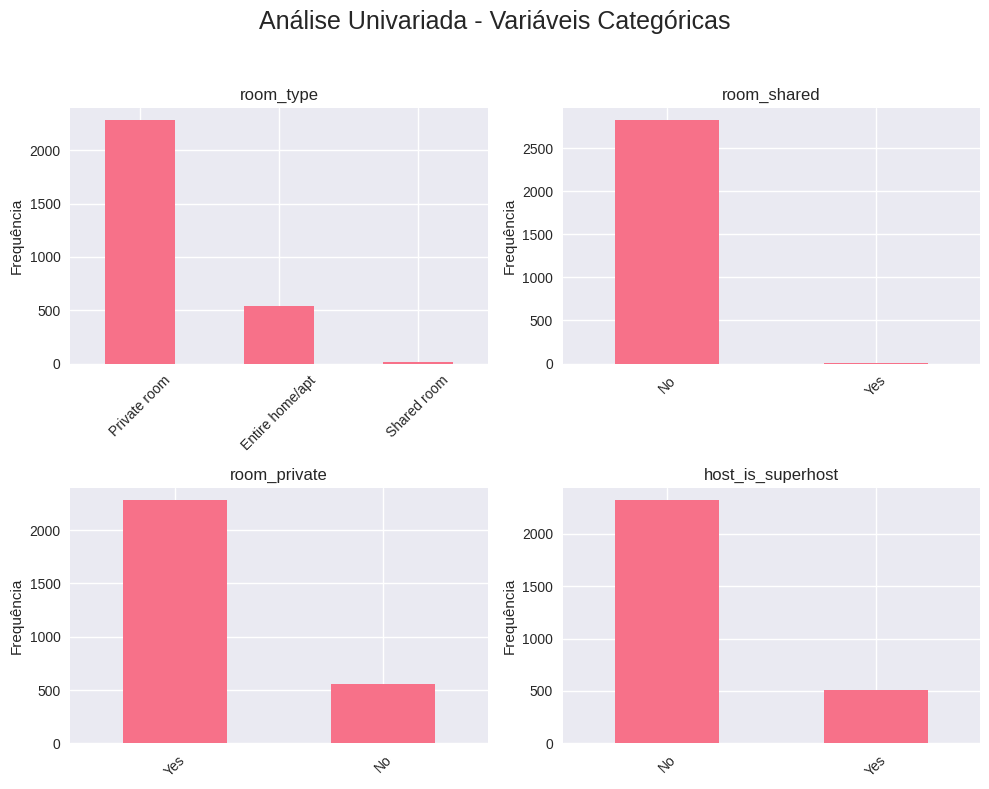

In [20]:
# escolha do número de colunas
cols = 2
rows = math.ceil(len(categorical_vars)/2)

fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
if not isinstance(axes, np.ndarray):
        axes = np.array([axes])
axes = axes.flatten()  # facilita indexação mesmo quando rows*cols == 1

fig.suptitle('Análise Univariada - Variáveis Categóricas', fontsize=18)

for idx, var in enumerate(categorical_vars):
        ax = axes[idx]

        if df[var].dtype == 'bool':
                counts = df[var].map({True:'Yes', False:'No'}).value_counts()
        else:
                counts = df[var].value_counts().head(10)  # top 10 categories for object columns

        counts.plot(kind='bar', ax=ax)
        ax.tick_params(axis='x', rotation=45)
        ax.set_xlabel('')
        ax.set_ylabel('Frequência')
        ax.set_title(f'{var}')
        # ajusta o layout deixando espaço para o suptitle

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


ANÁLISE EXPLORATÓRIA BIVARIADA

In [21]:
# 1. CORRELAÇÃO ENTRE VARIÁVEIS NUMÉRICAS
print("\n1️⃣ MATRIZ DE CORRELAÇÃO:")


1️⃣ MATRIZ DE CORRELAÇÃO:


In [22]:
# Calcular matriz de correlação
correlation_matrix = df[numeric_vars].corr()

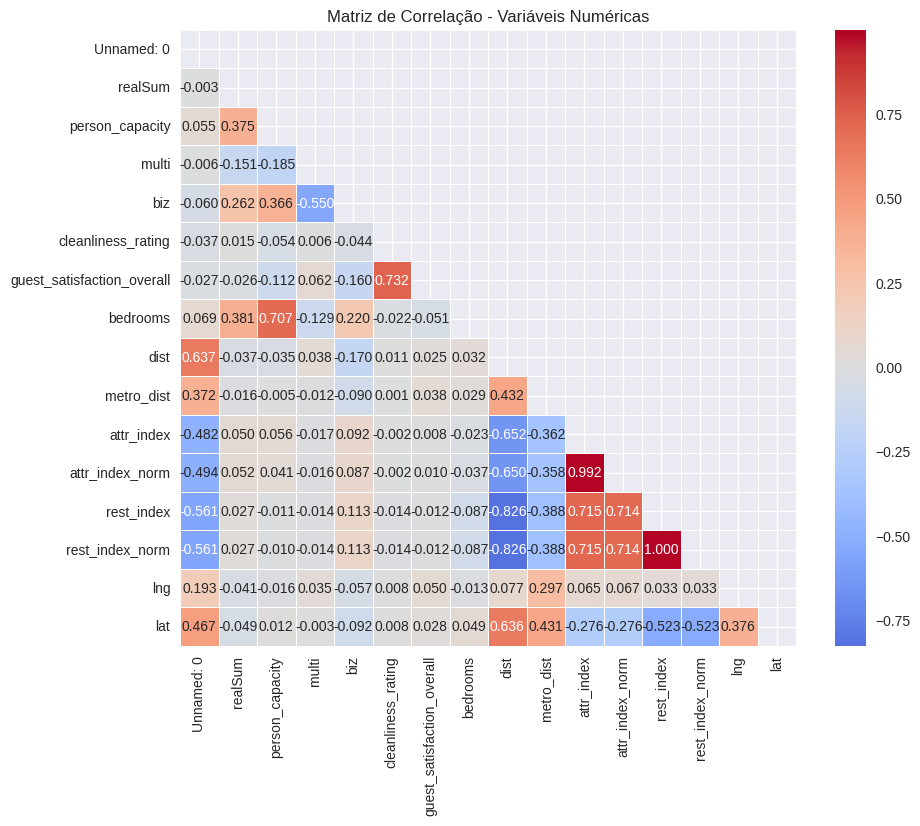

In [23]:
# Visualizar heatmap
plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, 
            mask=mask, 
            annot=True, 
            cmap='coolwarm',
            center=0, 
            square=True, 
            linewidths=0.5,
            fmt=".3f",)
plt.title('Matriz de Correlação - Variáveis Numéricas')
plt.show()

In [24]:
# Identificar correlações fortes
strong_corr = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        corr_val = correlation_matrix.iloc[i, j]
        if abs(corr_val) > 0.5:  # Correlação forte
            strong_corr.append({
                'var1': correlation_matrix.columns[i],
                'var2': correlation_matrix.columns[j],
                'correlation': corr_val
            })

In [25]:
if strong_corr:
    print("\n🔥 CORRELAÇÕES FORTES (|r| > 0.5):")
    for corr in strong_corr:
        print(f"  {corr['var1']} ↔ {corr['var2']}: {corr['correlation']:.3f}")


🔥 CORRELAÇÕES FORTES (|r| > 0.5):
  Unnamed: 0 ↔ dist: 0.637
  Unnamed: 0 ↔ rest_index: -0.561
  Unnamed: 0 ↔ rest_index_norm: -0.561
  person_capacity ↔ bedrooms: 0.707
  multi ↔ biz: -0.550
  cleanliness_rating ↔ guest_satisfaction_overall: 0.732
  dist ↔ attr_index: -0.652
  dist ↔ attr_index_norm: -0.650
  dist ↔ rest_index: -0.826
  dist ↔ rest_index_norm: -0.826
  dist ↔ lat: 0.636
  attr_index ↔ attr_index_norm: 0.992
  attr_index ↔ rest_index: 0.715
  attr_index ↔ rest_index_norm: 0.715
  attr_index_norm ↔ rest_index: 0.714
  attr_index_norm ↔ rest_index_norm: 0.714
  rest_index ↔ rest_index_norm: 1.000
  rest_index ↔ lat: -0.523
  rest_index_norm ↔ lat: -0.523


In [26]:
# 2. ANÁLISE TARGET vs VARIÁVEIS NUMÉRICAS
print("\n2️⃣ TARGET vs VARIÁVEIS NUMÉRICAS:")


2️⃣ TARGET vs VARIÁVEIS NUMÉRICAS:


In [27]:
num_cols = df.select_dtypes(include=['number']).columns.tolist()

corr = correlation_matrix['realSum'].abs().sort_values(ascending=False)

top3 = corr.index[1:4].tolist()  # Ignora o próprio realSum
print("Top 3 variáveis mais correlacionadas ao realSum:", top3)


Top 3 variáveis mais correlacionadas ao realSum: ['bedrooms', 'person_capacity', 'biz']


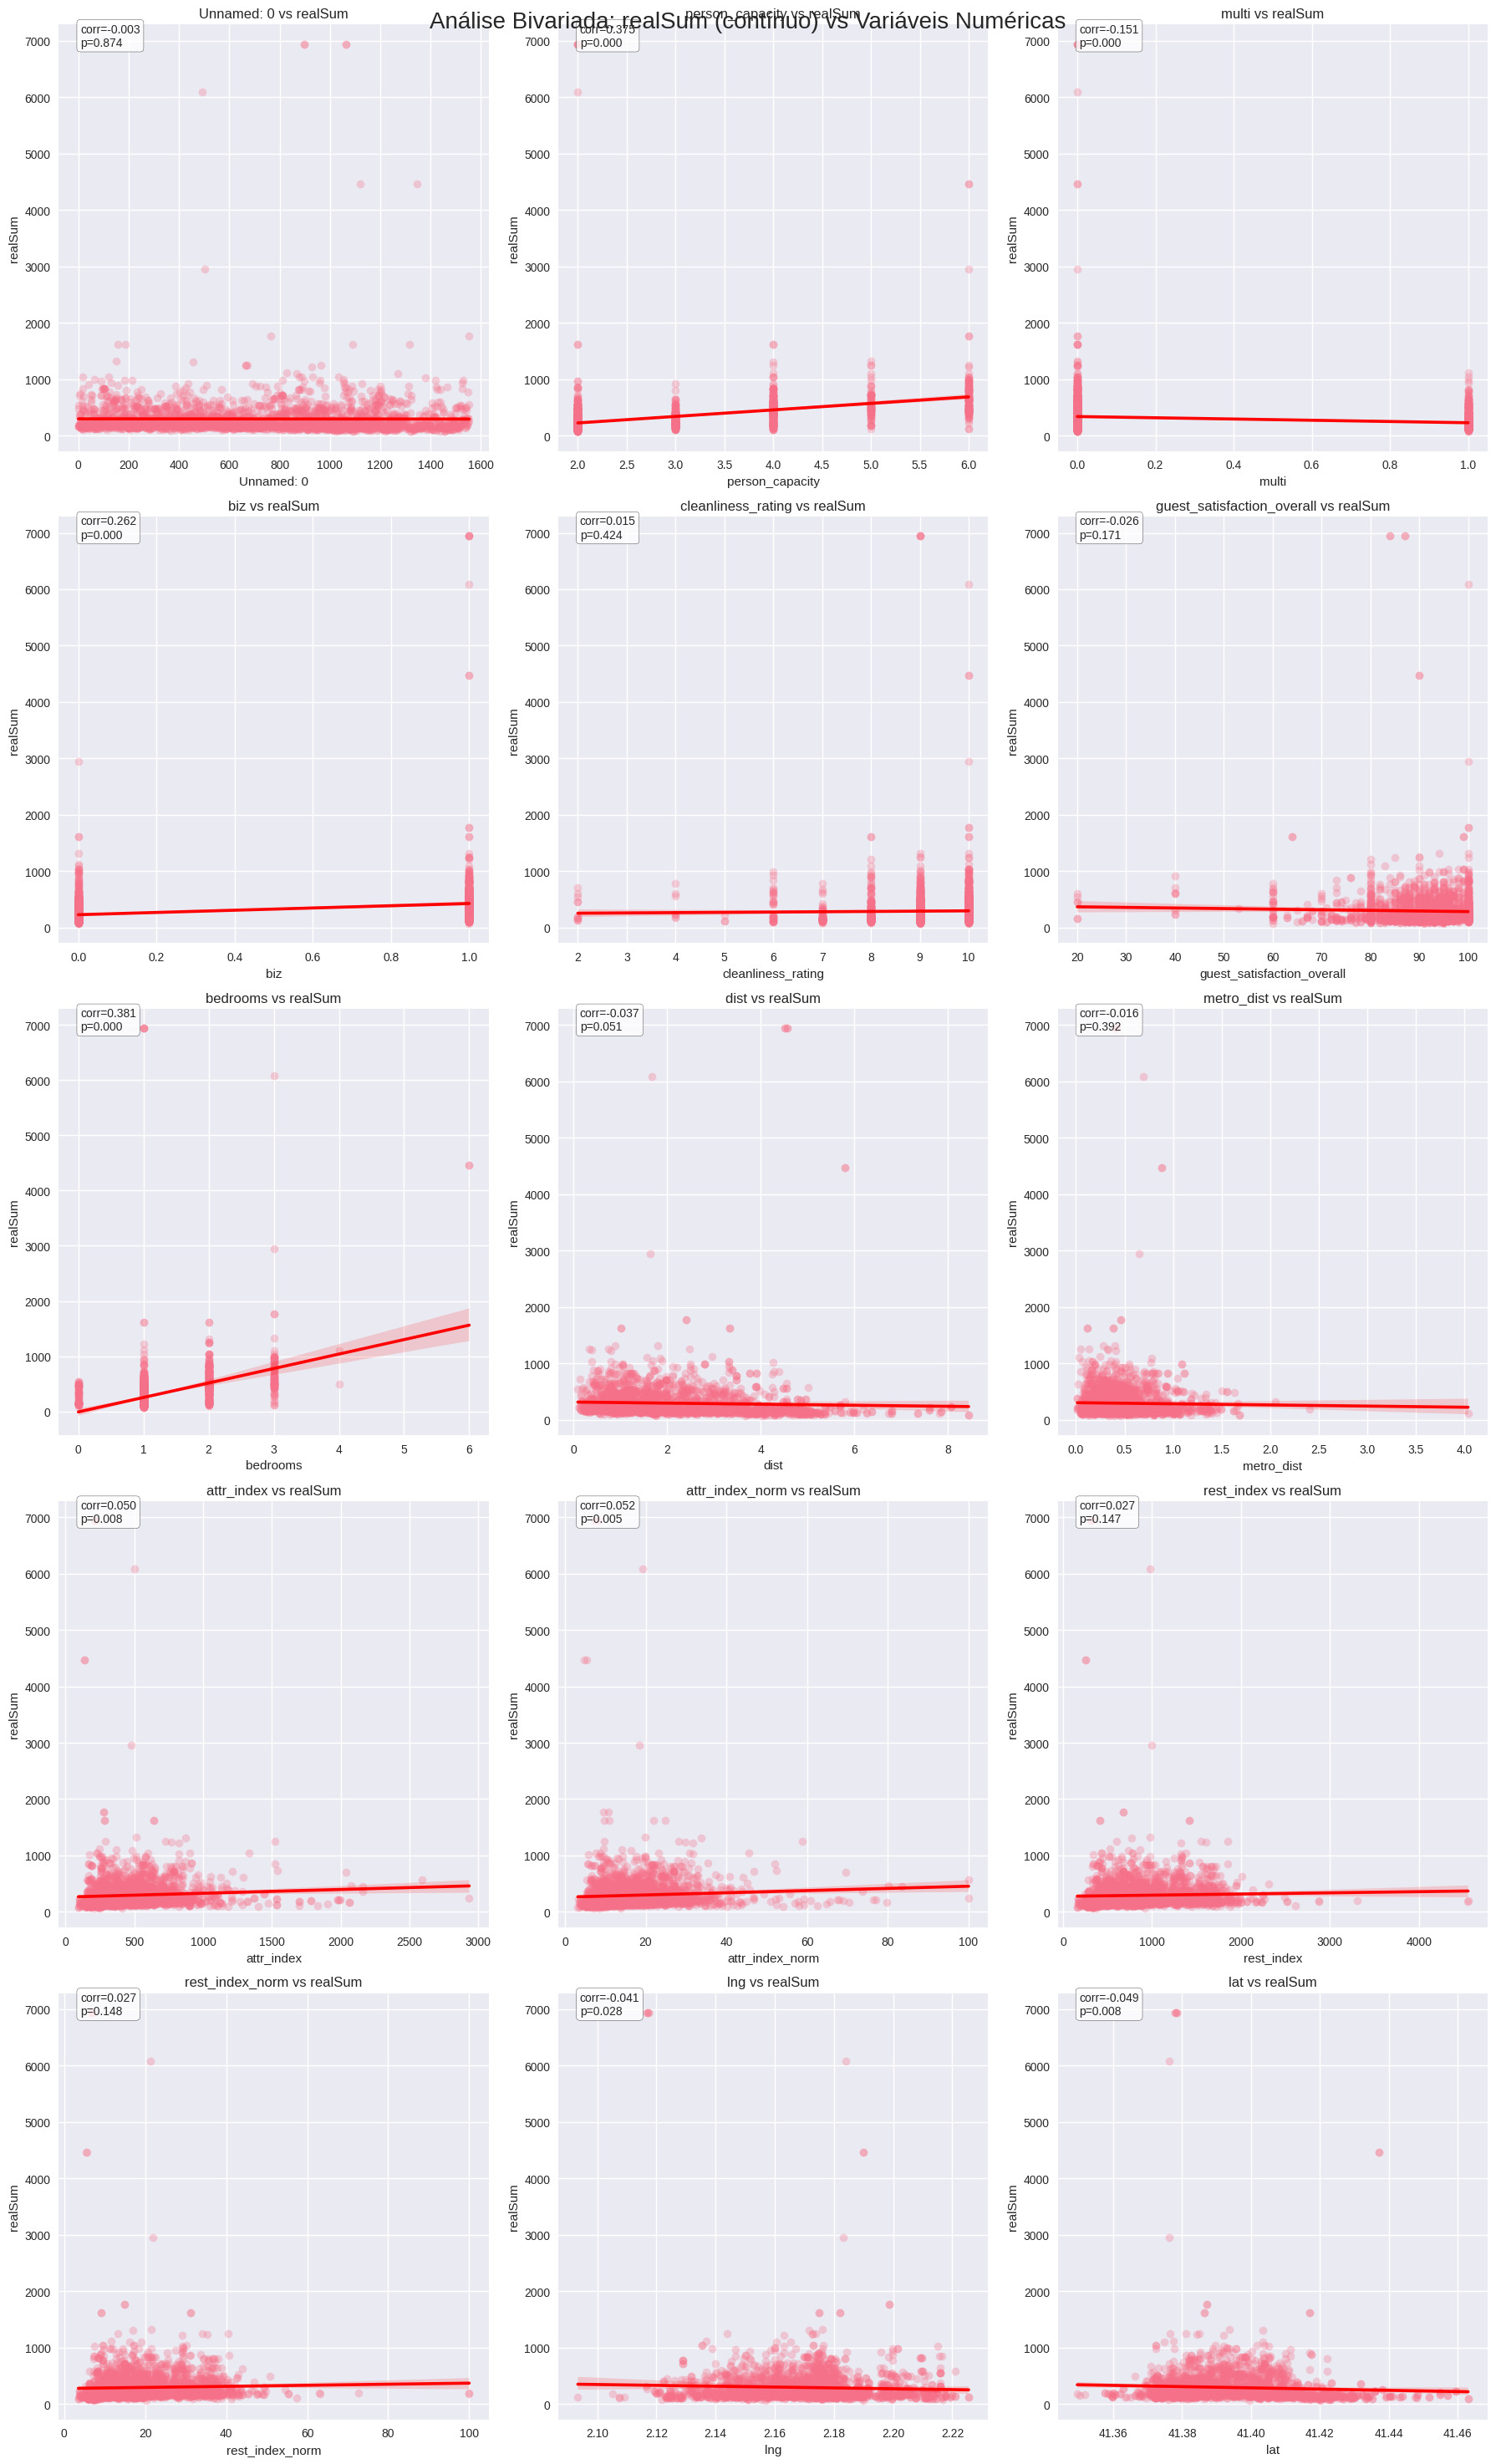

In [28]:

# Variáveis numéricas selecionadas para análise
target_var = 'realSum'
numeric_for_analysis = [var for var in numeric_vars if var != target_var]


n = len(numeric_for_analysis)
cols = 3
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(18, 6 * rows))
axes = axes.flatten()

fig.suptitle(f'Análise Bivariada: {target_var} (contínuo) vs Variáveis Numéricas', fontsize=20)

for i, var in enumerate(numeric_for_analysis):

    if var not in df.columns:
        continue

    ax = axes[i]

    # Scatter plot + regressão linear
    sns.regplot(
        data=df,
        x=var,
        y=target_var,
        scatter_kws={'alpha': 0.3},
        line_kws={'color': 'red'},
        ax=ax
    )
    
    ax.set_title(f'{var} vs {target_var}')

    # Correlação Pearson
    x = df[var].dropna()
    y = df[target_var].dropna()

    corr, pval = pearsonr(x, y)

    # Texto do p-value e correlação
    ax.text(
        0.05, 0.95,
        f'corr={corr:.3f}\np={pval:.3f}',
        transform=ax.transAxes,
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
    )

plt.tight_layout()
plt.show()


In [29]:
# 3. ANÁLISE TARGET vs VARIÁVEIS CATEGÓRICAS
print("\n3️⃣ TARGET vs VARIÁVEIS CATEGÓRICAS:")


3️⃣ TARGET vs VARIÁVEIS CATEGÓRICAS:


In [30]:
df["realSum_log"] = np.log1p(df["realSum"])


In [31]:
for var in categorical_vars:
    print(f"\n===== {var.upper()} =====")
    summary = df.groupby(var)["realSum"].agg(["count", "mean", "median", "std"]).round(2)
    print(summary)



===== ROOM_TYPE =====
                 count    mean  median     std
room_type                                     
Entire home/apt    542  629.86  497.59  684.09
Private room      2279  214.71  186.19  112.53
Shared room         12  124.07  111.02   29.73

===== ROOM_SHARED =====
             count    mean  median     std
room_shared                               
False         2821  294.48  208.53  356.05
True            12  124.07  111.02   29.73

===== ROOM_PRIVATE =====
              count    mean  median     std
room_private                               
False           554  618.90  491.77  680.65
True           2279  214.71  186.19  112.53

===== HOST_IS_SUPERHOST =====
                   count    mean  median     std
host_is_superhost                               
False               2319  292.92  203.64  378.99
True                 514  297.52  219.82  220.27


Variáveis válidas: ['room_type', 'room_shared', 'room_private', 'host_is_superhost']


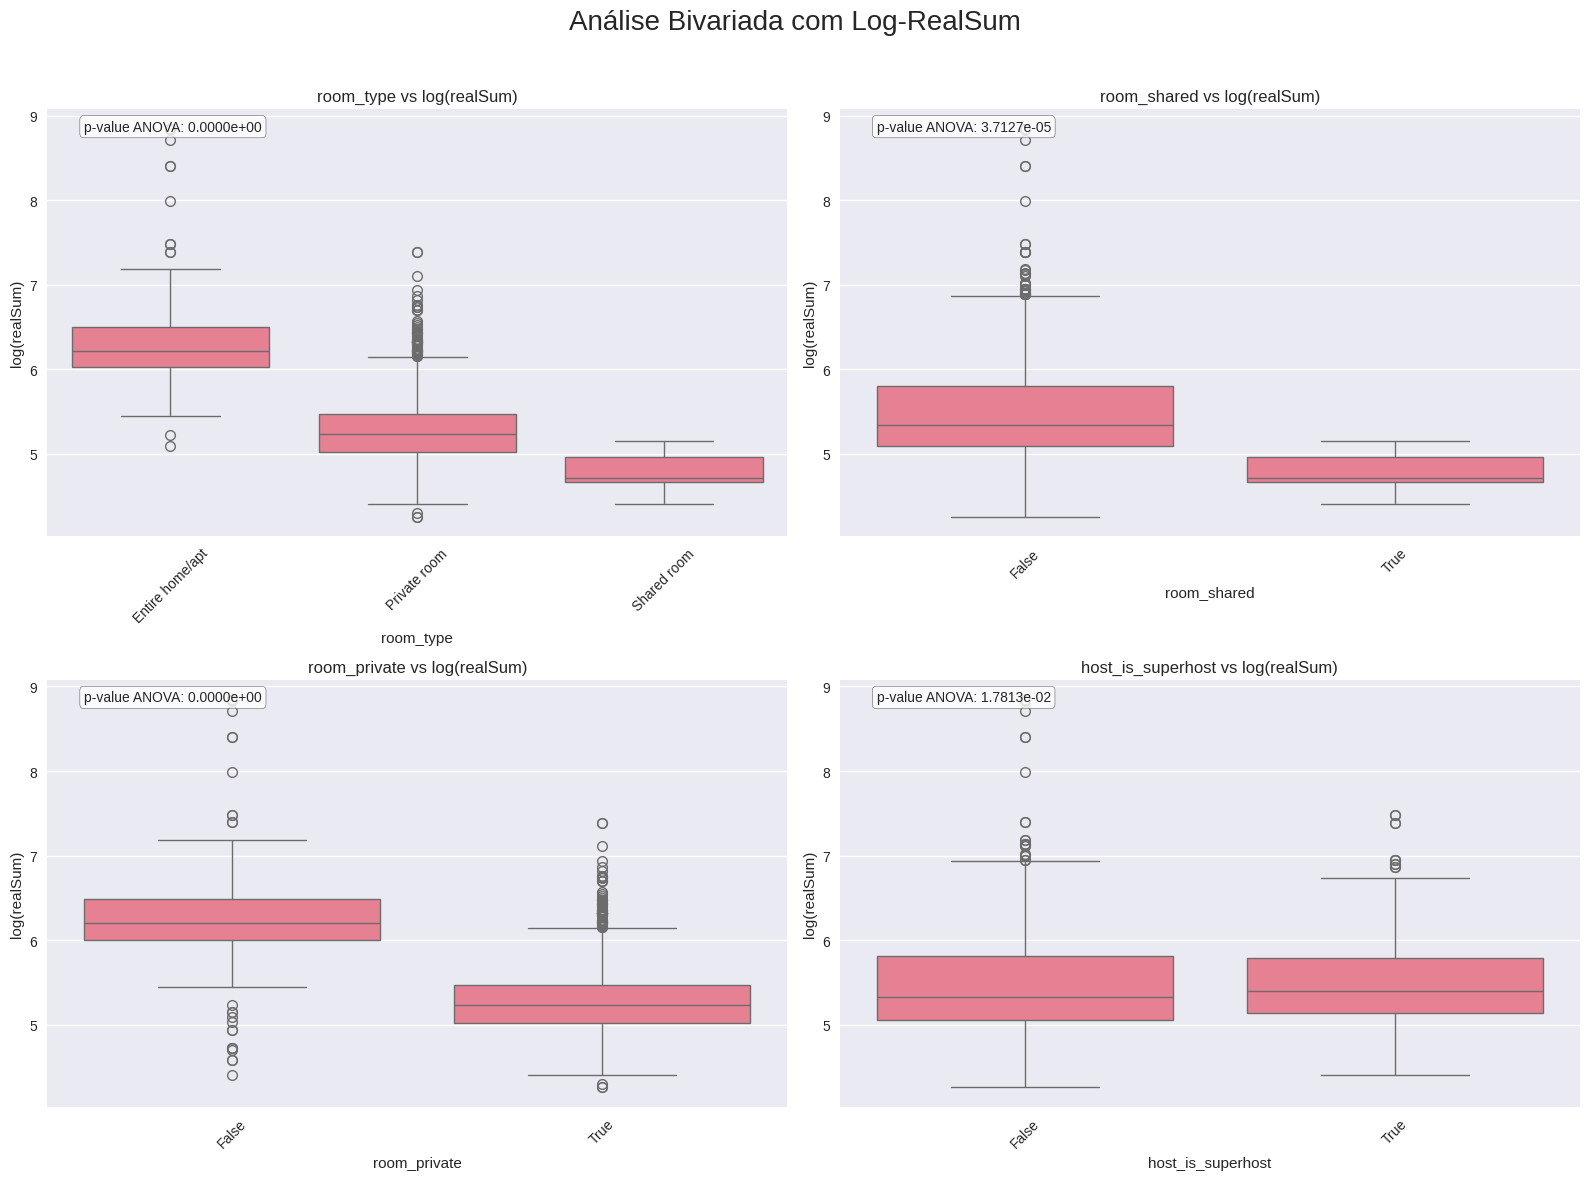

In [32]:
df = df[df["realSum"] > 0].copy()
df["realSum_log"] = np.log1p(df["realSum"])


# ✅ Filtrar apenas variáveis categóricas válidas
valid_categoricals = [
    var for var in categorical_vars
    if var in df.columns and df[var].nunique() > 1
]

print("Variáveis válidas:", valid_categoricals)

# ✅ PROTEÇÃO CONTRA LISTA VAZIA
if len(valid_categoricals) == 0:
    raise ValueError("Nenhuma variável categórica válida para plotar.")

cols = 2
rows = math.ceil(len(valid_categoricals) / cols)

fig, axes = plt.subplots(rows, cols, figsize=(16, 6 * rows))
axes = axes.flatten()

fig.suptitle("Análise Bivariada com Log-RealSum", fontsize=20)

for i, var in enumerate(valid_categoricals):
    ax = axes[i]

    sns.boxplot(data=df, x=var, y="realSum_log", ax=ax)

    ax.set_title(f'{var} vs log(realSum)')
    ax.set_ylabel("log(realSum)")
    ax.tick_params(axis='x', rotation=45)

    # ✅ ANOVA segura
    groups = [df[df[var] == c]["realSum_log"].dropna() for c in df[var].dropna().unique()]

    if len(groups) >= 2:
        f_stat, p_value = stats.f_oneway(*groups)
        ax.text(
            0.05, 0.95,
            f'p-value ANOVA: {p_value:.4e}',
            transform=ax.transAxes,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
        )

# ✅ Remover eixos vazios
for j in range(len(valid_categoricals), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


Análise Espacial RealSum

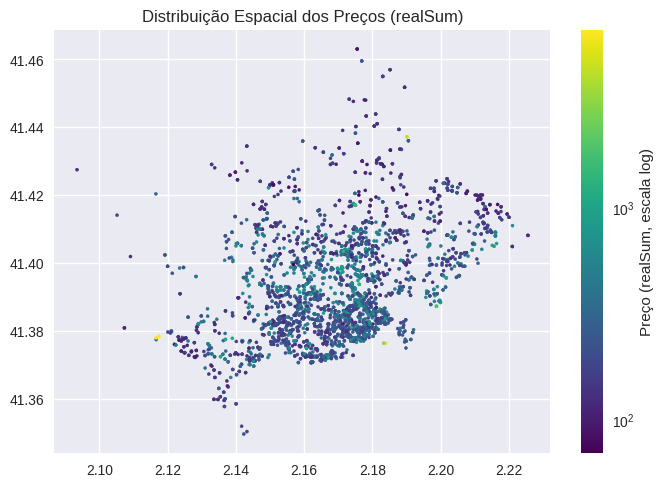

In [33]:
from matplotlib.colors import LogNorm

plt.scatter(
    df["lng"], df["lat"],
    c=df["realSum"],
    cmap="viridis",
    s=5,
    norm=LogNorm()
)
plt.colorbar(label="Preço (realSum, escala log)")
plt.title("Distribuição Espacial dos Preços (realSum)")
plt.show()


Análise Multivalorada

In [34]:
# 2. Análise de grupos interessantes
print("\n2️⃣ ANÁLISE DE GRUPOS:")


2️⃣ ANÁLISE DE GRUPOS:


In [36]:
# Faixa de preço (4 quantis)
df['Price_Group'] = pd.qcut(df['realSum'], q=4,
                            labels=['Baixo', 'Médio-Baixo', 'Médio-Alto', 'Alto'])

# Faixa de distância do centro
df['Dist_Group'] = pd.qcut(
    df['dist'],
    q=4,
    labels=['Muito perto', 'Perto', 'Longe', 'Muito Longe'],
    duplicates='drop'   # evita erro se existirem valores repetidos
)

# Faixa de satisfação
df['Satisfaction_Group'] = pd.cut(
    df['guest_satisfaction_overall'],
    bins=[0, 60, 80, 95, 100],
    labels=['Baixa', 'Média', 'Alta', 'Excelente']
)

# Capacidade categorizada
df['Capacity_Group'] = df['person_capacity'].map({
    2: 'Pequeno',
    4: 'Médio',
    6: 'Grande'
})


In [37]:
analysis = df.groupby(['room_type', 'host_is_superhost'])['guest_satisfaction_overall'] \
             .agg(['mean', 'count']) \
             .round(2)

print("\n📊 SATISFAÇÃO MÉDIA POR TIPO DE QUARTO E SUPERHOST:")
print(analysis)



📊 SATISFAÇÃO MÉDIA POR TIPO DE QUARTO E SUPERHOST:
                                    mean  count
room_type       host_is_superhost              
Entire home/apt False              87.75    450
                True               96.46     92
Private room    False              90.47   1858
                True               96.41    421
Shared room     False              88.73     11
                True               96.00      1


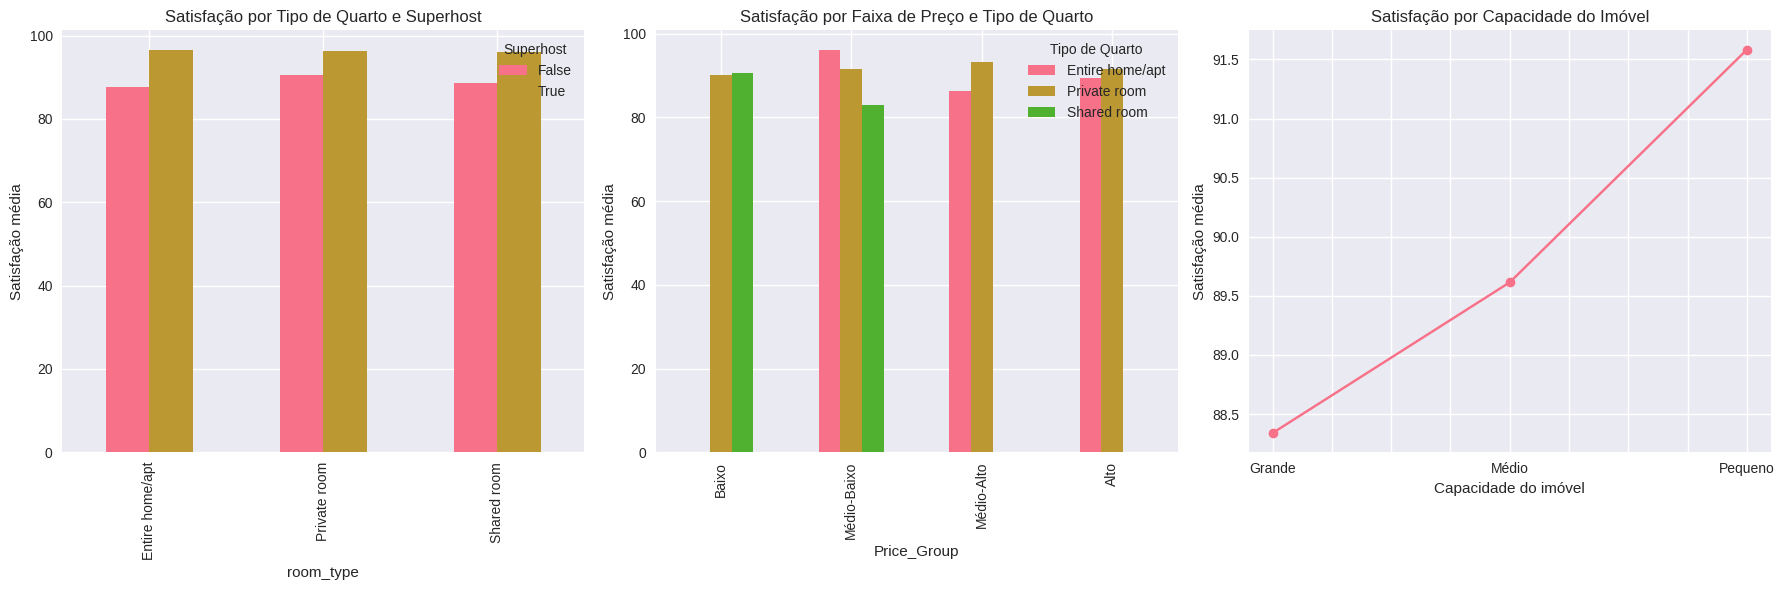

In [38]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1 — Por tipo de quarto
s_room = df.groupby(['room_type', 'host_is_superhost'])['guest_satisfaction_overall'] \
           .mean().unstack()

s_room.plot(kind='bar', ax=axes[0])
axes[0].set_title('Satisfação por Tipo de Quarto e Superhost')
axes[0].set_ylabel('Satisfação média')
axes[0].legend(title='Superhost')

# 2 — Por faixa de preço
s_price = df.groupby(['Price_Group', 'room_type'])['guest_satisfaction_overall'] \
            .mean().unstack()

s_price.plot(kind='bar', ax=axes[1])
axes[1].set_title('Satisfação por Faixa de Preço e Tipo de Quarto')
axes[1].set_ylabel('Satisfação média')
axes[1].legend(title='Tipo de Quarto')

# 3 — Por capacidade
s_capacity = df.groupby('Capacity_Group')['guest_satisfaction_overall'].mean()

s_capacity.plot(kind='line', marker='o', ax=axes[2])
axes[2].set_title('Satisfação por Capacidade do Imóvel')
axes[2].set_ylabel('Satisfação média')
axes[2].set_xlabel('Capacidade do imóvel')

plt.tight_layout()
plt.show()
